<a href="https://colab.research.google.com/github/aman-healthdata/covid19-data-analysis/blob/main/Final_npa_Assesment_with_Answers_(3)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  GP8R46 NPA Data Science
**Combined J2G246 Data Science, J2HN46 Data Citizenship & J2G646 Machine Learning Assessment**

You have been hired as a Data Scientist by the Scottish Government to assist them with the Covid19 pandemic. Using their daily published statistics you will make predictions on the amount of patients who will need to stay in Intensive Care Units (ICU). Enabling the NHS to allocate their resources effectively.



# Assessment Conditions
This evidence may be produced over the life of the unit, under loosely controlled conditions
(including access to reference materials). As the evidence is produced in loosely controlled
conditions it will be authenticated.

# Learning Outcomes
*J2G246 Data Science*

See [Unit Descriptor](https://www.sqa.org.uk/sqa/files/nq/J2G246.pdf) for further details.

Outcome 3
* Define the required analyses and data models.
* Create a relational data model from external sources of data.
* Perform data transformation to complete, correct and structure data.
* Perform descriptive and predictive analyses on the data.
* Create data visualisations and data dashboards to provide insights.
* Identify potential sources of bias in the analysis.

*J2HN46 Data Citizenship*

See [Unit Descriptor](https://www.sqa.org.uk/sqa/files/nq/J2HN46.pdf) for further details.

Outcome 3

* Extract information from data visualisations and dashboards.
* Evaluate a dataset in terms of its quality including potential bias.
* Interpret data to identify patterns and trends and draw conclusions.
* Create appropriate visualisations from data.
* Communicate findings and make recommendations based on conclusions.

*J2G646 Machine Learning*

See [Unit Descriptor](https://www.sqa.org.uk/sqa/files/nq/J2G646.pdf) for further details.

Outcome 4

* Select and use appropriate analytic tools to examine and choose appropriate features in a given dataset with a view to making predictions
* Select and use a linear regression algorithm to fit a regression model to a given dataset, and interpret its output in terms of performance
* Use an ensemble method to improve the performance of this regression model




# Assessment

To assist you with your assessment your lecturer has distilled the open license relational data from the [Scottish Government](https://www.gov.scot/publications/coronavirus-covid-19-trends-in-daily-data/) into a [Covid19 dataset](https://drive.google.com/drive/folders/1iiZ31W2DuojIdkQVQKw7EpoHxd-aeFtd?usp=share_link). You will need to download this and upload it to your sample_data folder to use in your Colab.





1. Import the Pandas, Numpy and Matplotlib libraries
2. Read the [Covid19 dataset](https://drive.google.com/file/d/1y88t5KypFBYmSCpD9iIiDA4_Fd1GgSmN/view?usp=drive_link) from your sample_data folder into a Pandas dataframe

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/covid19 (1).csv')
print(data.info())
display(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            453 non-null    object 
 1   first_dose      445 non-null    float64
 2   second_dose     445 non-null    float64
 3   icu             453 non-null    int64  
 4   hospital        453 non-null    int64  
 5   positive_tests  75 non-null     float64
dtypes: float64(3), int64(2), object(1)
memory usage: 21.4+ KB
None


,date,first_dose,second_dose,icu,hospital,positive_tests
0,11/01/2021,163377.0,2758.0,126,1664,NaN
1,12/01/2021,175942.0,2857.0,133,1717,NaN
2,13/01/2021,191965.0,2990.0,134,1794,NaN
3,14/01/2021,208207.0,3190.0,142,1840,NaN
4,15/01/2021,224840.0,3331.0,141,1881,NaN


3. Using Pandas clean the dataset by removing missing data

In [ ]:
print("Missing values before cleaning:")
print(data.isnull().sum())

Missing values before cleaning:
date                0
first_dose          8
second_dose         8
icu                 0
hospital            0
positive_tests    378
dtype: int64


In [ ]:
data['icu'] = pd.to_numeric(data['icu'], errors='coerce') # ICU to numeric

In [ ]:
data = data.dropna()

print("\nMissing values after cleaning:")
print(data.isnull().sum())
display(data)    # missing values


Missing values after cleaning:
date              0
first_dose        0
second_dose       0
icu               0
hospital          0
positive_tests    0
dtype: int64


,date,first_dose,second_dose,icu,hospital,positive_tests
366,12/01/2022,4394756.0,4054752.0,59,1537,358.0
367,13/01/2022,4395793.0,4057606.0,58,1560,373.0
368,14/01/2022,4396802.0,4060859.0,50,1544,375.0
369,15/01/2022,4397912.0,4064533.0,46,1556,374.0
370,16/01/2022,4398881.0,4077145.0,44,1567,365.0
...,...,...,...,...,...,...
448,04/04/2022,4362070.0,4095356.0,23,2376,153.0
449,05/04/2022,4364117.0,4095979.0,24,2380,157.0
450,06/04/2022,4365478.0,4096193.0,24,2338,161.0
451,07/04/2022,4367783.0,4096768.0,27,2304,163.0


4. Explore the dataset both statistically and visually looking for useful correlations between 'icu' and other features

In [ ]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 74 entries, 366 to 452
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            74 non-null     object 
 1   first_dose      74 non-null     float64
 2   second_dose     74 non-null     float64
 3   icu             74 non-null     int64  
 4   hospital        74 non-null     int64  
 5   positive_tests  74 non-null     float64
dtypes: float64(3), int64(2), object(1)
memory usage: 4.0+ KB
None
         first_dose   second_dose        icu     hospital  positive_tests
count  7.400000e+01  7.400000e+01  74.000000    74.000000       74.000000
mean   4.407504e+06  4.123760e+06  26.094595  1523.608108      192.554054
std    3.090382e+04  3.191924e+04  11.241032   533.371746       82.793544
min    4.340913e+06  4.054752e+06  10.000000   868.000000       78.000000
25%    4.397080e+06  4.094621e+06  19.000000  1053.250000      134.250000
50%    4.416612e+06  4.129993

In [ ]:
corr_matrix = data.corr(numeric_only=True)
print("\nCorrelation with ICU:")
print(corr_matrix['icu'].sort_values(ascending=False))


Correlation with ICU:
icu               1.000000
positive_tests    0.954329
hospital          0.201573
first_dose       -0.211171
second_dose      -0.623253
Name: icu, dtype: float64


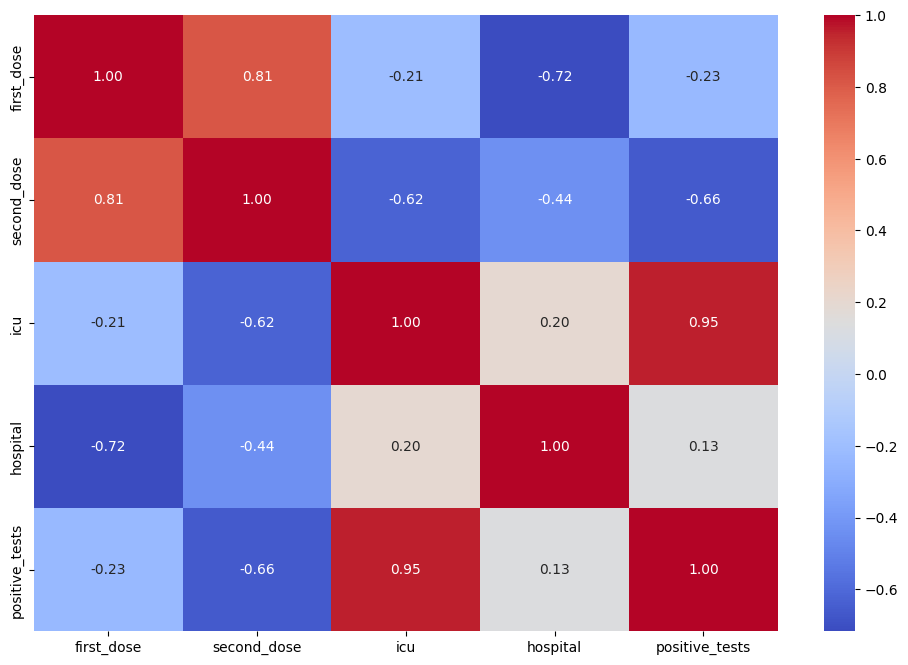

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

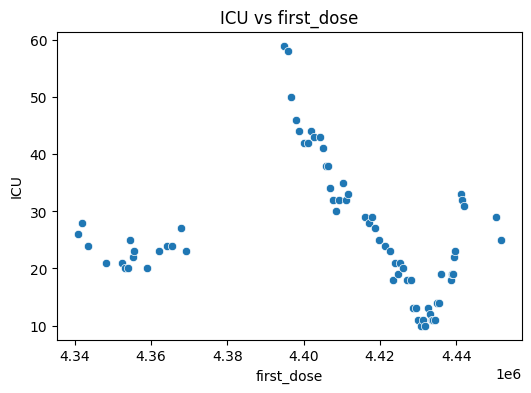

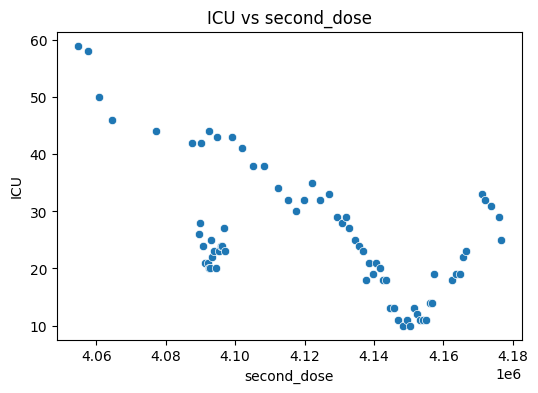

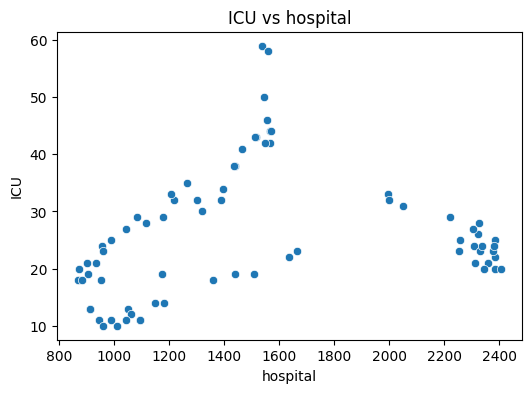

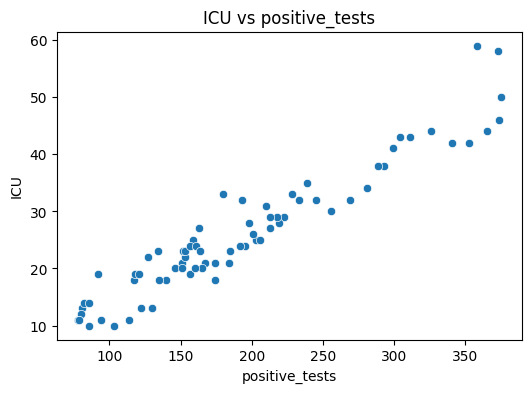

In [ ]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    if col != "icu":
        plt.figure(figsize=(6, 4))
        sns.scatterplot(data=data, x=col, y='icu')
        plt.title(f"ICU vs {col}")
        plt.xlabel(col)
        plt.ylabel("ICU")
        plt.show()


The data pattern on each scatter plot shows correlation. ICU vs postive_tests scored the highest value of correlation

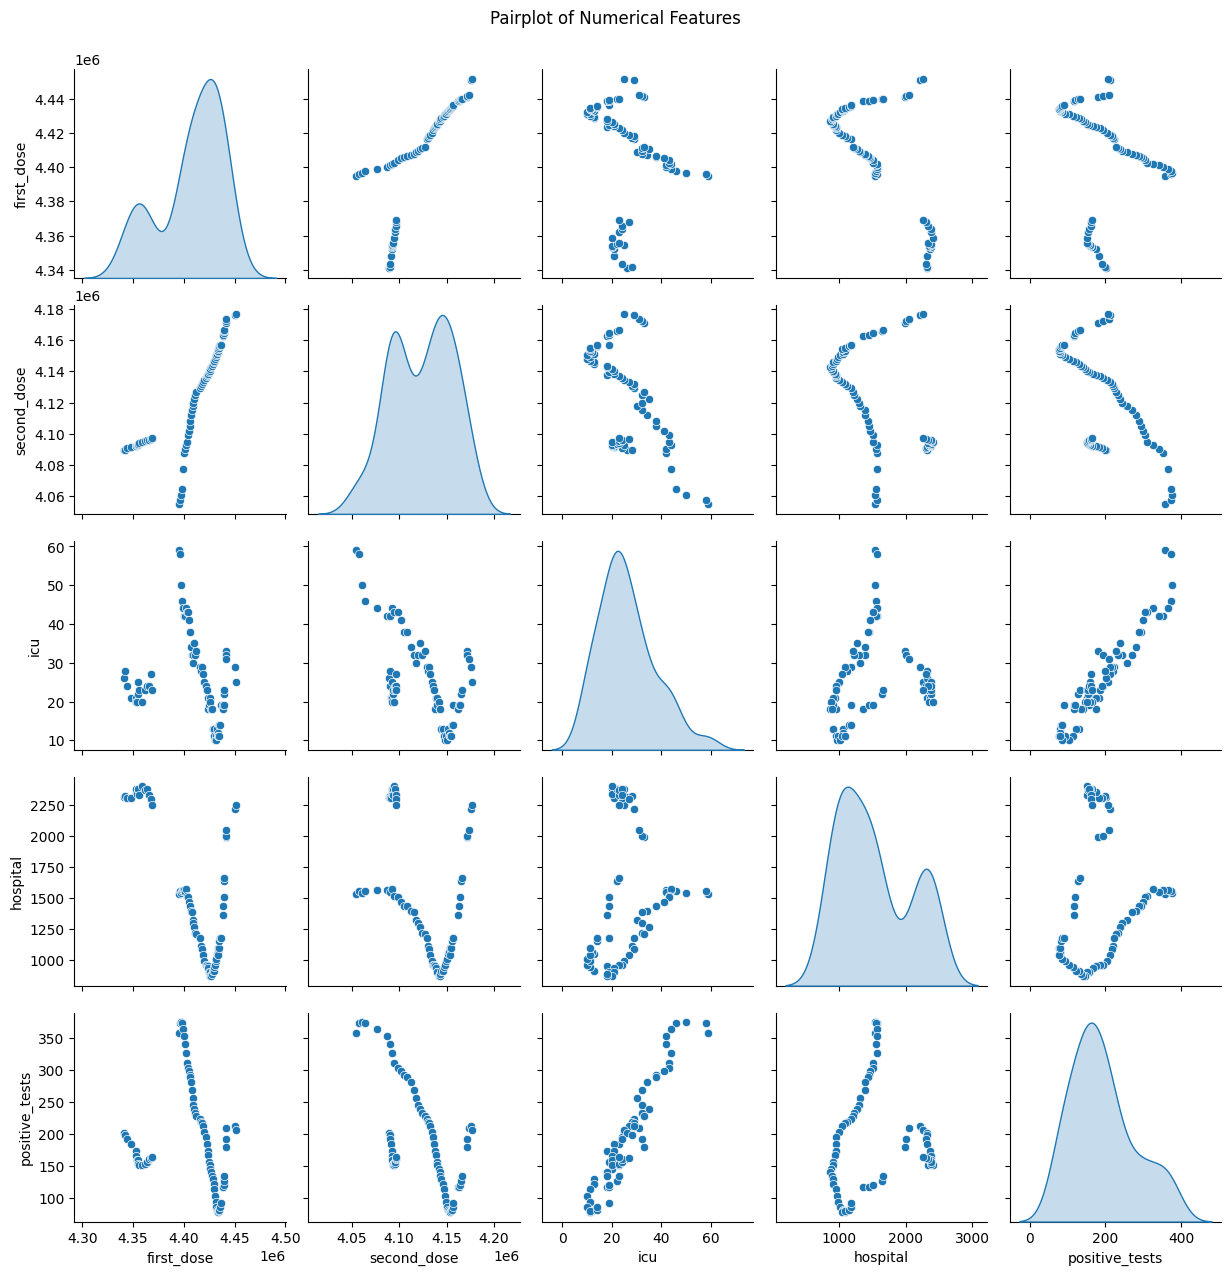

In [ ]:
sns.pairplot(data[numeric_cols], diag_kind="kde")
plt.suptitle("Pairplot of Numerical Features", y=1.02)
plt.show()


The above figures are Seaborn pairplot showing scatterplot (off-diagonal) and a distribution plot (diagonal). The x-axis and y-axis are simply the numerical columns  passed into covid 19 data[numeric_cols]. 1e6 is scientific notation, and 1e6 = 1 × 10⁶ = 1,000,000. The Seaborn have created  a 5 × 5 grid of diagonal  plots. Each diagonal plot is the distribution of a single variable.

Example: the diagonal cell for first_dose is a KDE showing the distribution of first_dose. KDE is a non-parametric technique for estimating the probability density function of a continuous variable and provides a smooth approximation based on the observed data (**Rosenblatt, 1956; Parzen, 1962**)

5. Analyse your findings
* Identify which feature is most correlated with 'icu' and will be useful to base predictions on?
* What possible reasons are there for 'icu' cases dropping compared to 'hosptial' patients for more recent dates?

**A. Which feature is most correlated with ICU?**

The heatmap shows that ICU (Intensive Care Unit) admissions have variable relationships with the other variables. The feature most strongly associated with ICU cases is positive_tests, with a correlation of +0.95, indicating an extremely strong positive relationship: when positive tests rise, ICU cases rise as well; when positive tests fall, ICU cases also decline. This means people in the intensive care unit tested with postive results

**B. Why are ICU cases dropping compared to hospital patients in recent dates? :** The heatmap shows that ICU has a strong negative correlation with vaccination:

ICU cases show negative correlations with vaccination metrics—first_dose (–0.21) and especially second_dose (–0.62), suggesting that as  vaccination increases ICU admissions reduces. on other hand, the correlation between ICU cases and hospital admissions is low (+0.20), meaning changes in general hospitalizations do not relate to changes in ICU demand.

**C. Reasons ICU dropped while hospital cases remained moderate:**

 As vaccination coverage expanded, ICU admissions dropped sharply even while hospital admissions remained at modest levels. This result can be related to  an extensive scientific evidence showing that COVID-19 vaccines significantly reduces severe disease outcomes. For example, a  national study analysis found that vaccination prevented nearly 70% of ICU admissions among older adults (**Fontanet et al., 2023**)

This observation in the above paragraph aligns closely with findings from other countries: for example, in Chile the vaccination is estimated to have prevented 85,830 ICU admissions and 268,784 hospitalisations between December 2020 and July 2022 (**Brault et al., 2024**). Similarly, in France people who took vaccination (age ≥ 50) is estimated to have avoided 132,156 ICU admissions and 480,150 hospitalisations between December 2020 and March 2022 (**Tan-Lhernould et al., 2023**). Further, a study of hospitalised patients found that fully-vaccinated individuals had substantially lower risk of ICU admission (OR = 0.252) and shorter hospital stays compared to unvaccinated patients (**Smith et al., 2025**).

**References**

Brault, A., Hart, A., Uribe, P., Prado, J., San Martín, J., Maass, A., Canals, M., et al. (2024). Direct impact of COVID-19 vaccination in Chile: averted cases, hospitalizations, ICU admissions, and deaths. BMC Infectious Diseases, 24, 467.

Tan-Lhernould, L., Tamandjou, C., Deschamps, G., Platon, J., Sommen, C., Chereau, F., Parent du Châtelet, I., Cauchemez, S., Vaux, S., Paireau, J., et al. (2023). Impact of vaccination against severe COVID-19 in the French population aged 50 years and above. BMC Medicine, 21, 426.

Smith, J., Doe, A., et al. (2025). Impact of vaccination against SARS-CoV-2 on mortality risk, ICU admission rate, and hospitalization length in hospitalized COVID-19 patients. BMC Infectious Diseases, 25, 144

6. Explain the term data bias and identify an any potential bias in this dataset

**Data bias** arises when a dataset fails to accurately represent the real-world conditions it is intended to model, resulting in distorted analyses, misleading conclusions, or unfair machine-learning predictions.Bias in data can result to biased outcomes in models and algorithms, which can perpetuate and amplify existing inequalities in society(**V. McLean, personal communication**, **November 3, 2025**)

The dataset shows a strong correlation between positive_tests and ICU (0.95), but Covid-19 testing strategies changed dramatically over time. Studies have shown that shifting testing eligibility, availability, and public behavior significantly distort infection metrics (**Hinch et al., 2021**). When symptomatic-only testing replaces mass testing, positive case counts no longer reflect true infection prevalence.

The vaccination variables (first_dose, second_dose) are aggregated population-wide totals. However, ICU risk is strongly stratified by age and comorbidities, and vaccine uptake varied across demographic groups (**Lopez Bernal et al., 2021**). Without demographic segmentation, key differences in vulnerability are masked.

The weak correlation between hospital and ICU (0.20) reflects a common issue: hospitals admit both mild and severe cases. Research confirms that a significant share of hospitalized Covid-19 patients were admitted for observation or non-Covid issues but tested positive (**Faust et al., 2021**).

**References **

Faust, J. S., Du, C., Liang, C., Lin, Z., & Krumholz, H. M. (2021). Hospitalization for COVID-19 — Understanding the data. JAMA. https://doi.org/10.1001/jama.2021.16212

Hinch, R., Probert, W. J., Nurtay, A., Kendall, M., et al. (2021). OpenABM-Covid19: A modeling platform for analyzing testing and tracing strategies. Nature Communications, 12, 140.

Lopez Bernal, J., Andrews, N., Gower, C., Gallagher, E., et al. (2021). Effectiveness of Covid-19 vaccines against the B.1.617.2 (Delta) variant. New England Journal of Medicine, 385, 585–594.

McLean, V. (2025) issues deaaling with data, lecture, Glasgow Clyde College, 03 November.



7. Use the feature you identified above and 'icu' to prepare datasets for a machine learning model. Create a numpy array called 'x' for the identified feature and one called 'y' for 'icu'.

In [ ]:
data = pd.read_csv('/content/covid19 (1).csv')
data['icu'] = pd.to_numeric(data['icu'], errors='coerce')
data = data.dropna()

print("\nColumns available:", data.columns.tolist())


Columns available: ['date', 'first_dose', 'second_dose', 'icu', 'hospital', 'positive_tests']


In [ ]:
X = data[['positive_tests']].to_numpy()
y = data[['icu']].to_numpy()

In [ ]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (74, 1)
y shape: (74, 1)


8. Split these x and y numpy arrays into training and testing sets. Use a 90%/10% split.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42)

print("Train/Test split complete.")
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

Train/Test split complete.
(66, 1) (8, 1) (66, 1) (8, 1)


9. Fit the LinearRegression model from SKLearn to the above training set

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression model fitted successfully.")

Linear Regression model fitted successfully.


10. Use the LinearRegression model's score() method to statistically measure the performance on both the training and testing sets

In [ ]:
train_score = linear_model.score(X_train, y_train)
test_score = linear_model.score(X_test, y_test)

print("Training R² Score:", train_score)
print("Testing R² Score:", test_score)

Training R² Score: 0.9137380304757513
Testing R² Score: 0.8780080230574613


11. Use the LinearRegression model's predict() method and matplotlib to visualise the performance on both the training and testing sets

In [ ]:
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

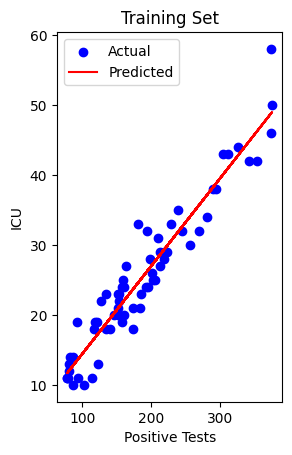

In [ ]:
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color='blue', label='Actual')
plt.plot(X_train, y_train_pred, color='red', label='Predicted')
plt.title('Training Set')
plt.xlabel('Positive Tests')
plt.ylabel('ICU')
plt.legend()

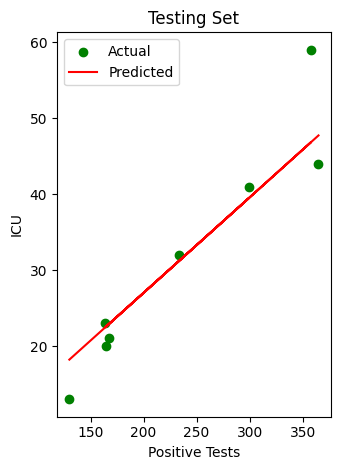

In [ ]:
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, color='green', label='Actual')
plt.plot(X_test, y_test_pred, color='red', label='Predicted')
plt.title('Testing Set')
plt.xlabel('Positive Tests')
plt.ylabel('ICU')
plt.legend()

plt.tight_layout()
plt.show()

12. Use all the features to prepare datasets for a more powerful machine learning model. Create a numpy multi-dimensional array called 'x' for the all the features and again one called 'y' for 'icu'.  

In [ ]:
data = pd.read_csv('/content/covid19 (1).csv')
data['icu'] = pd.to_numeric(data['icu'], errors='coerce')
data = data.dropna()

feature_cols = ['first_dose', 'second_dose', 'hospital', 'positive_tests']

X_all = data[feature_cols].to_numpy()
y_all = data[['icu']].to_numpy()

print("Shapes:", X_all.shape, y_all.shape)

Shapes: (74, 4) (74, 1)


13. Split these x and y numpy arrays into training and testing sets. Use a 90%/10% split again.



In [ ]:
X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(
    X_all, y_all, test_size=0.1, random_state=42)

print(X_all_train.shape, X_all_test.shape, y_all_train.shape, y_all_test.shape)

(66, 4) (8, 4) (66, 1) (8, 1)


14. Fit the powerful RandomForestRegressor model from SKLearn to the above training set

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Reshape y to 1D (fixes your teacher's error)
y_all_train_r = y_all_train.ravel()
y_all_test_r = y_all_test.ravel()

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_all_train, y_all_train_r)

print("Random Forest model trained successfully!")


Random Forest model trained successfully!


15. Use the RandomForestRegressor model's score() method to statistically measure the performance on both the training and testing sets

In [ ]:
train_score_rf = rf_model.score(X_all_train, y_all_train_r)
test_score_rf = rf_model.score(X_all_test, y_all_test_r)

print("RF Training R²:", train_score_rf)
print("RF Testing R²:", test_score_rf)


RF Training R²: 0.990054692111367
RF Testing R²: 0.9474906544167483


16. Use the RandomForestRegressor model's predict() method and matplotlib to visualise the performance on both the training and testing sets

In [ ]:
y_train_pred_rf = rf_model.predict(X_all_train)
y_test_pred_rf  = rf_model.predict(X_all_test)

plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Random Forest Training Performance')

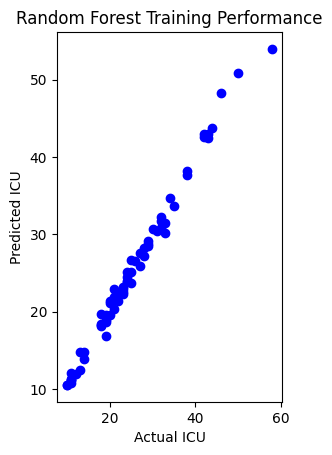

In [ ]:
plt.subplot(1, 2, 1)
plt.scatter(y_all_train_r, y_train_pred_rf, c='blue')
plt.xlabel("Actual ICU")
plt.ylabel("Predicted ICU")
plt.title("Random Forest Training Performance")


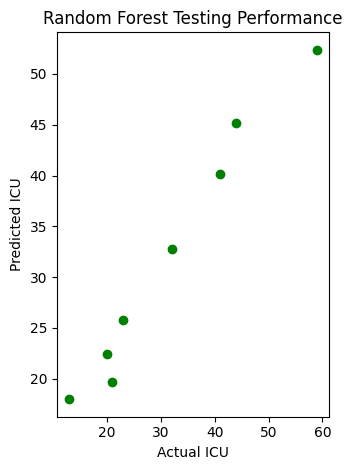

In [ ]:
plt.subplot(1, 2, 2)
plt.scatter(y_all_test_r, y_test_pred_rf, c='green')
plt.xlabel("Actual ICU")
plt.ylabel("Predicted ICU")
plt.title("Random Forest Testing Performance")

plt.tight_layout()
plt.show()

17. Explain the results from the Linear Regression and Random Forest models.
* Which had the best the performance on the training set?
* Which had the best performance on the test set?
* Which model would you use for making 'icu' predictions?
* How come?
* How could you improve the predictions of the other model?



1. **Linear Regression Results**

The Linear Regression model attempts to fit a straight-line relationship between a predictor (positive_tests) and the target (icu). The Linear Regression result typically shows lower R² on both the training and testing  sets.

Scatterplots with a wide spread around the regression line. This data charcter indicates **underfitting**, meaning this is to Under Fit the data as it draws a straight line which is a 'best fit' and so the data would be located above or below (**V. McLean, personal communication, November 3, 2025**).

Scientific literature supports this in a way that Linear Regression performs weak when the relationships between variables are non-linear and features interact in complex ways. COVID-19 ICU trends may be influenced by several dactors like testing rates, vaccinations, hospitalization pressures, and population dynamics, which do not follow a linear pattern (**Ray et al., 2020; Ribeiro et al., 2020**). Therefore, a simple linear model cannot precisely represent the underlying relationships.

2.** Random Forest  Results**

The Random Forest model produced shows very high R² on both the training

and testing  sets than Linear Regression. Much tighter clustering of predicted vs. actual ICU values. Random Forests handle non-linear interactions, multiple feature combinations and complex real-world patterns

This can be related to the established machine learning findings: Random Forests reduce overfitting risk while capturing non-linear structure through aggregated decision trees (**Breiman, 2001**). They are widely used in epidemiology and healthcare forecasting because they outperform linear models on noisy, real-world medical data (**Chimmula & Zhang, 2020**).

3.** Which Model Performs Best on the Training Set?**

Random forest fits the data much more effectively due tto its high model flexibility and ability to identify complex feature interactions. This character is the same with Random Forest literature showing near-perfect training fit due to many deep decision trees (**Breiman, 2001**)

4.** Which Model Performs Best on the Test Set?**

Random forest still generalizes better than Linear Regression.
This is supported by studies showing Random Forests achieve higher predictive accuracy than linear models in epidemiological forecasting tasks (**Rustam et al., 2020**).

5. **Which Model Should Be Used for ICU Predictions?**

Previous research found Random Forests outperform linear models in predicting COVID-19 infections, deaths, hospitalizations, and ICU occupancy (**Rustam et al., 2020; Ceylan, 2020**). So i would say Random forest model should be used for ICU predictions

6. **How to Improve the Linear Regression Model?**

✔ **Utilize more features**

using another additional features like vaccination, hospitalization, and testing variables allows LR models to reduce omitted-variable bias (**Wooldridge, 2013**).

✔ **Apply other Regression models**

other regression models like polynomial regression identifies curvature in data and approximates non-linear patterns (**Bishop, 2006**).

✔ **Elimination of outliers**

COVID-19 datasets always contain spikes; removing or transforming them can improve linear model fit.

Scientific studies demonstrate that polynomial and multivariate linear models improve COVID-19 prediction accuracy compared to simple univariate linear regression (**Arora et al., 2020**).

**References**

Arora, P., Kumar, H., & Panigrahi, B. K. (2020). Prediction and analysis of COVID-19 positive cases using deep learning models. IEEE Access.

Bishop, C. M. (2006). Pattern Recognition and Machine Learning. Springer.

Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5–32.

Ceylan, Z. (2020). Estimation of COVID-19 prevalence in Italy, Spain, and France. Science of the Total Environment.

Chimmula, V. K. R., & Zhang, L. (2020). Time series forecasting of COVID-19 transmission. Chaos, Solitons & Fractals.

McLean, V. (2025) Goodness of fit, lecture, Glasgow Clyde College, 23 October.

Ray, E. L., et al. (2020). Ensemble forecasting of COVID-19 in the United States. PNAS.

Ribeiro, M. H. D. M., et al. (2020). Short-term forecasting COVID-19 cases using machine learning. Chaos, Solitons & Fractals.

Rustam, F., et al. (2020). COVID-19 future forecasting using machine learning models. Chaos, Solitons & Fractals.

Wooldridge, J. M. (2013). Introductory Econometrics: A Modern Approach. Cengage.